# Feature Engineering

## Objective

Transform the validated transaction dataset into machine learning-ready feature datasets.

Input:
datasets/master/master_transactions.csv

Outputs:

- expense_features.csv
- forecasting_features.csv
- merchant_features.csv

This notebook performs:

- Feature planning
- Feature creation
- Validation
- Dataset generation

In [1]:
# Importing libraries

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATASET_DIR = PROJECT_ROOT / "data"
MASTER_DIR = DATASET_DIR / "master"
PROCESSED_DIR = DATASET_DIR / "processed"
FEATURE_STORE_DIR = DATASET_DIR / "feature_store"
METADATA_DIR = PROJECT_ROOT / "metadata"

In [3]:
#Loaded the Dataset
master_file = MASTER_DIR / "final_master_transaction.csv"


In [4]:
df = pd.read_csv(master_file)

In [5]:
df.head()

,transaction_id,transaction_date,transaction_time,merchant,description,amount,currency,payment_method,transaction_type,category,city,state,country,day,week,month,weekend,month_end,salary_week,festival_season
0,TXN000001,2018-01-01,09:22:10,Credit Card Bill Payment,Auto Debit Credit Card Bill Payment,4361.84,INR,Auto Debit,Debit,Bills,Bengaluru,Karnataka,India,1,1,1,0,0,1,0
1,TXN000002,2018-01-01,12:33:23,Zepto,UPI/Paytm/Zepto,1226.03,INR,UPI,Debit,Groceries,Bengaluru,Karnataka,India,1,1,1,0,0,1,0
2,TXN000003,2018-01-01,20:17:30,Ace Hardware India,POS Purchase Ace Hardware India,523.73,INR,Credit Card,Debit,Miscellaneous,Bengaluru,Karnataka,India,1,1,1,0,0,1,0
3,TXN000004,2018-01-01,21:33:19,Zepto,UPI/DR/623175732898/Zepto,1290.29,INR,UPI,Debit,Groceries,Indore,Madhya Pradesh,India,1,1,1,0,0,1,0
4,TXN000005,2018-01-02,08:43:33,House Rent Payment,NEFT Rent Payment,44800.94,INR,NEFT,Debit,Rent,Pune,Maharashtra,India,2,1,1,0,0,1,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    7000 non-null   object 
 1   transaction_date  7000 non-null   object 
 2   transaction_time  7000 non-null   object 
 3   merchant          7000 non-null   object 
 4   description       7000 non-null   object 
 5   amount            7000 non-null   float64
 6   currency          7000 non-null   object 
 7   payment_method    7000 non-null   object 
 8   transaction_type  7000 non-null   object 
 9   category          7000 non-null   object 
 10  city              7000 non-null   object 
 11  state             7000 non-null   object 
 12  country           7000 non-null   object 
 13  day               7000 non-null   int64  
 14  week              7000 non-null   int64  
 15  month             7000 non-null   int64  
 16  weekend           7000 non-null   int64  


In [7]:
df.dtypes

transaction_id       object
transaction_date     object
transaction_time     object
merchant             object
description          object
amount              float64
currency             object
payment_method       object
transaction_type     object
category             object
city                 object
state                object
country              object
day                   int64
week                  int64
month                 int64
weekend               int64
month_end             int64
salary_week           int64
festival_season       int64
dtype: object

In [8]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

In [9]:
df["transaction_time"] = pd.to_datetime(df["transaction_time"], format='%H:%M:%S')

In [10]:
df.dtypes

transaction_id              object
transaction_date    datetime64[ns]
transaction_time    datetime64[ns]
merchant                    object
description                 object
amount                     float64
currency                    object
payment_method              object
transaction_type            object
category                    object
city                        object
state                       object
country                     object
day                          int64
week                         int64
month                        int64
weekend                      int64
month_end                    int64
salary_week                  int64
festival_season              int64
dtype: object

In [11]:
df.shape

(7000, 20)

In [12]:
# Verify Required Columns

required_columns = [
    "transaction_date",
    "merchant",
    "description",
    "amount",
    "payment_method",
    "transaction_type",
    "category"
]

missing = [col for col in required_columns if col not in df.columns]

if missing:
    print("Missing columns:", missing)
else:
    print("All required columns are available.")

All required columns are available.


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    7000 non-null   object        
 1   transaction_date  7000 non-null   datetime64[ns]
 2   transaction_time  7000 non-null   datetime64[ns]
 3   merchant          7000 non-null   object        
 4   description       7000 non-null   object        
 5   amount            7000 non-null   float64       
 6   currency          7000 non-null   object        
 7   payment_method    7000 non-null   object        
 8   transaction_type  7000 non-null   object        
 9   category          7000 non-null   object        
 10  city              7000 non-null   object        
 11  state             7000 non-null   object        
 12  country           7000 non-null   object        
 13  day               7000 non-null   int64         
 14  week              7000 n

In [14]:
df.shape

(7000, 20)

In [15]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time', 'merchant',
       'description', 'amount', 'currency', 'payment_method',
       'transaction_type', 'category', 'city', 'state', 'country', 'day',
       'week', 'month', 'weekend', 'month_end', 'salary_week',
       'festival_season'],
      dtype='object')

In [16]:
df.columns.tolist()

['transaction_id',
 'transaction_date',
 'transaction_time',
 'merchant',
 'description',
 'amount',
 'currency',
 'payment_method',
 'transaction_type',
 'category',
 'city',
 'state',
 'country',
 'day',
 'week',
 'month',
 'weekend',
 'month_end',
 'salary_week',
 'festival_season']

In [17]:
feature_plan = pd.DataFrame({
    "Column": df.columns,
    "Type": [
        "Identifier",
        "Datetime",
        "Datetime",
        "Text",
        "Text",
        "Numeric",
        "Categorical",
        "Categorical",
        "Categorical",
        "Target",
        "Categorical",
        "Categorical",
        "Categorical",
        "Numeric",
        "Numeric",
        "Numeric",
        "Binary",
        "Binary",
        "Binary",
        "Binary"
    ]
})

feature_plan

,Column,Type
0,transaction_id,Identifier
1,transaction_date,Datetime
2,transaction_time,Datetime
3,merchant,Text
4,description,Text
5,amount,Numeric
6,currency,Categorical
7,payment_method,Categorical
8,transaction_type,Categorical
9,category,Target


In [18]:
feature_usage = pd.DataFrame({
    "Feature": [
        "merchant",
        "description",
        "amount",
        "payment_method",
        "transaction_type",
        "day",
        "week",
        "month",
        "weekend",
        "month_end",
        "salary_week",
        "festival_season"
    ],

    "Expense_Model": [
        "Yes","Yes","Yes","Yes","Yes",
        "No","No","No","No","No","No","No"
    ],

    "Forecast_Model": [
        "No","No","Yes","No","No",
        "Yes","Yes","Yes","Yes","Yes","Yes","Yes"
    ],

    "Merchant_Analytics": [
        "Yes","No","Yes","No","No",
        "No","No","No","No","No","No","No"
    ]
})

feature_usage

,Feature,Expense_Model,Forecast_Model,Merchant_Analytics
0,merchant,Yes,No,Yes
1,description,Yes,No,No
2,amount,Yes,Yes,Yes
3,payment_method,Yes,No,No
4,transaction_type,Yes,No,No
5,day,No,Yes,No
6,week,No,Yes,No
7,month,No,Yes,No
8,weekend,No,Yes,No
9,month_end,No,Yes,No


In [19]:
df.nunique()

transaction_id      7000
transaction_date     653
transaction_time    6655
merchant              99
description         1176
amount              6587
currency               1
payment_method         8
transaction_type       2
category              13
city                  15
state                 11
country                1
day                   31
week                  52
month                 12
weekend                2
month_end              2
salary_week            2
festival_season        2
dtype: int64

In [20]:
categorical_cols = [
    "currency",
    "payment_method",
    "transaction_type",
    "category",
    "city",
    "state",
    "country"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


currency
currency
INR    7000
Name: count, dtype: int64

payment_method
payment_method
UPI                2607
Auto Debit         1333
Debit Card         1053
Net Banking         816
Credit Card         697
NEFT                307
Cash Withdrawal      95
IMPS                 92
Name: count, dtype: int64

transaction_type
transaction_type
Debit     6810
Credit     190
Name: count, dtype: int64

category
category
Bills            2059
Food             1328
Groceries         912
Shopping          550
Other             435
Fuel              423
Miscellaneous     358
Subscription      242
Salary            173
Entertainment     167
Rent              165
Insurance         152
Investment         36
Name: count, dtype: int64

city
city
Bengaluru    1015
Indore        452
Nagpur        450
Pune          447
Noida         444
Mumbai        434
Delhi         432
Kochi         432
Hyderabad     431
Chennai       431
Jaipur        431
Lucknow       422
Surat         410
Kolkata       391
Ahmedabad

In [21]:
status = [
    "Excluded",   # transaction_id
    "Selected",   # transaction_date
    "Future",     # transaction_time
    "Selected",   # merchant
    "Selected",   # description
    "Selected",   # amount
    "Excluded",   # currency
    "Selected",   # payment_method
    "Selected",   # transaction_type
    "Target",     # category
    "Future",     # city
    "Future",     # state
    "Excluded",   # country
    "Selected",   # day
    "Selected",   # week
    "Selected",   # month
    "Selected",   # weekend
    "Selected",   # month_end
    "Selected",   # salary_week
    "Selected"    # festival_season
]

reason = [
    "Unique transaction identifier; not useful for prediction.",
    "Required for chronological ordering and forecasting.",
    "Reserved for future hour-of-day and time-based features.",
    "Strong indicator of transaction category and merchant analytics.",
    "Provides transaction context for NLP-based classification.",
    "Core numerical feature used across multiple models.",
    "Constant value (INR); provides no predictive information.",
    "Useful categorical feature indicating payment channel.",
    "Distinguishes debit and credit transactions.",
    "Prediction target for expense classification; category label for analytics.",
    "Useful for future regional spending analysis and visualization.",
    "Useful for future regional spending analysis and visualization.",
    "Constant value (India); provides no predictive information.",
    "Captures day-of-month spending patterns.",
    "Captures weekly spending patterns.",
    "Captures monthly spending trends.",
    "Captures weekday vs weekend spending behaviour.",
    "Captures month-end spending behaviour.",
    "Captures salary-cycle spending behaviour.",
    "Captures seasonal/festival spending behaviour."
]

feature_plan["Status"] = status
feature_plan["Reason"] = reason

In [22]:
feature_plan

,Column,Type,Status,Reason
0,transaction_id,Identifier,Excluded,Unique transaction identifier; not useful for ...
1,transaction_date,Datetime,Selected,Required for chronological ordering and foreca...
2,transaction_time,Datetime,Future,Reserved for future hour-of-day and time-based...
3,merchant,Text,Selected,Strong indicator of transaction category and m...
4,description,Text,Selected,Provides transaction context for NLP-based cla...
5,amount,Numeric,Selected,Core numerical feature used across multiple mo...
6,currency,Categorical,Excluded,Constant value (INR); provides no predictive i...
7,payment_method,Categorical,Selected,Useful categorical feature indicating payment ...
8,transaction_type,Categorical,Selected,Distinguishes debit and credit transactions.
9,category,Target,Target,Prediction target for expense classification; ...


### Creating transaction-text

In [ ]:
df[['merchant' , 'description']].isnull().sum()

merchant       0
description    0
dtype: int64

In [23]:
# creating transaction-text feature

df['transaction_text'] = (
    df['merchant'].fillna('').astype(str).str.strip()
    + " " +
    df['description'].fillna('').astype(str).str.strip()
).str.strip()

In [25]:
df[["merchant", "description", "transaction_text"]].head(10)

,merchant,description,transaction_text
0,Credit Card Bill Payment,Auto Debit Credit Card Bill Payment,Credit Card Bill Payment Auto Debit Credit Car...
1,Zepto,UPI/Paytm/Zepto,Zepto UPI/Paytm/Zepto
2,Ace Hardware India,POS Purchase Ace Hardware India,Ace Hardware India POS Purchase Ace Hardware I...
3,Zepto,UPI/DR/623175732898/Zepto,Zepto UPI/DR/623175732898/Zepto
4,House Rent Payment,NEFT Rent Payment,House Rent Payment NEFT Rent Payment
5,Credit Card Bill Payment,Net Banking Payment Credit Card Bill Payment,Credit Card Bill Payment Net Banking Payment C...
6,Swiggy,UPI/Paytm/Swiggy,Swiggy UPI/Paytm/Swiggy
7,McDonald's India,UPI/DR/200262210949/McDonald's India,McDonald's India UPI/DR/200262210949/McDonald'...
8,BookMyShow,UPI Payment BookMyShow,BookMyShow UPI Payment BookMyShow
9,Ajio,POS Purchase Ajio,Ajio POS Purchase Ajio


In [26]:
df["transaction_text"].sample(10, random_state=42)

6500                     Tata Power Auto Debit Tata Power
2944                     Indian Oil Debit Card Indian Oil
2024    Credit Card Bill Payment Auto Debit Credit Car...
263                              DMart POS Purchase DMart
4350                            Bharat Gas UPI/Bharat Gas
3424                        BEST Net Banking Payment BEST
6748                                  Blinkit UPI/Blinkit
6215                                BSNL Net Banking BSNL
6362                           Ajio UPI/DR/695020389/Ajio
5589               Amazon India POS Purchase Amazon India
Name: transaction_text, dtype: object

In [27]:
df['transaction_text'].isnull().sum()

np.int64(0)

In [28]:
df["transaction_text"].duplicated().sum()

np.int64(5791)

In [29]:
# calculating the length of transaction_text

df["transaction_text_length"] = df["transaction_text"].str.len()

In [30]:
df['transaction_text_length'].describe()

count    7000.000000
mean       36.537286
std        13.960665
min        11.000000
25%        25.000000
50%        33.000000
75%        44.000000
max        73.000000
Name: transaction_text_length, dtype: float64

In [31]:
df.nlargest(
    10,
    "transaction_text_length"
)[["transaction_text", "transaction_text_length"]]

,transaction_text,transaction_text_length
187,Municipal Water Department UPI/DR/687816574852...,73
546,Municipal Water Department UPI/DR/911478777325...,73
628,Municipal Water Department UPI/DR/020876231693...,73
733,Municipal Water Department Net Banking Payment...,73
869,Municipal Water Department Net Banking Payment...,73
1174,Municipal Water Department UPI/DR/311563015268...,73
1193,Municipal Water Department Net Banking Payment...,73
1588,Municipal Water Department Net Banking Payment...,73
1597,Municipal Water Department Net Banking Payment...,73
1758,Municipal Water Department UPI/DR/616338874599...,73


In [32]:
df.nsmallest(
    10,
    "transaction_text_length"
)[["transaction_text", "transaction_text_length"]]

,transaction_text,transaction_text_length
2801,Jio UPI/Jio,11
2997,Ola UPI/Ola,11
3330,Jio UPI/Jio,11
3781,Jio UPI/Jio,11
3800,Ola UPI/Ola,11
3878,Ola UPI/Ola,11
4155,Jio UPI/Jio,11
4312,Jio UPI/Jio,11
4480,Jio UPI/Jio,11
4552,Ola UPI/Ola,11


In [33]:
print("Missing values:", df["transaction_text"].isnull().sum())
print("Duplicate texts:", df["transaction_text"].duplicated().sum())
print("Average length:", round(df["transaction_text"].str.len().mean(), 2))
print("Minimum length:", df["transaction_text"].str.len().min())
print("Maximum length:", df["transaction_text"].str.len().max())

Missing values: 0
Duplicate texts: 5791
Average length: 36.54
Minimum length: 11
Maximum length: 73


In [34]:
df["transaction_text"].value_counts().head(20)

transaction_text
Credit Card Bill Payment Auto Debit Credit Card Bill Payment             369
Credit Card Bill Payment Net Banking Payment Credit Card Bill Payment    273
Employer Salary Credit NEFT Salary Credit                                163
Airtel Auto Debit Airtel                                                  85
Municipal Water Department Auto Debit Municipal Water Department          79
Amazon India POS Purchase Amazon India                                    70
Jio Auto Debit Jio                                                        67
Spotify Auto Debit Spotify                                                60
Jio Fiber Auto Debit Jio Fiber                                            58
BSNL Auto Debit BSNL                                                      57
House Rent Payment NEFT Rent Payment                                      56
Zomato UPI/Paytm/Zomato                                                   55
Flipkart POS Purchase Flipkart                             

In [35]:
df["transaction_text"].nunique()

1209

### Amount Log 
To Convert skewed data into normal distribution 

Many ML algorithms don't perform as well with heavily skewed data because the largest values dominate.

In [36]:
df.amount.describe()

count      7000.000000
mean       4989.675896
std       13768.784894
min          30.740000
25%         489.030000
50%        1382.480000
75%        3620.717500
max      240125.840000
Name: amount, dtype: float64

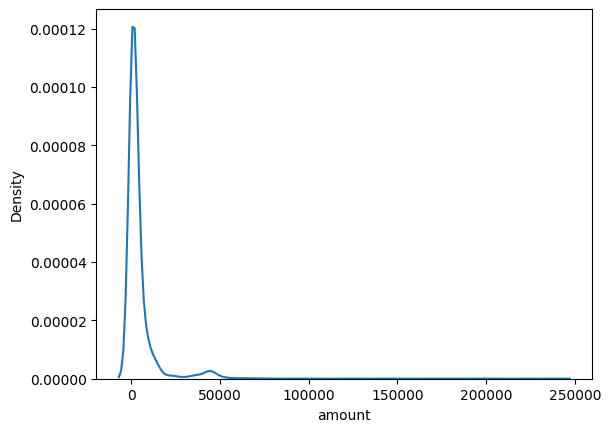

In [37]:
sns.kdeplot(df['amount'])
plt.show()

In [38]:
df['amount'].skew()

np.float64(8.374869780946938)

A skewness of 8.374869780946938 is extremely highly skewed in the positive (right) direction

In [39]:
df['amount_log'] = np.log1p(df['amount'])

In [40]:
df[["amount", "amount_log"]].head(10)

,amount,amount_log
0,4361.84,8.380879
1,1226.03,7.112352
2,523.73,6.262884
3,1290.29,7.163397
4,44800.94,10.710007
5,2761.36,7.923841
6,268.49,5.596531
7,306.84,5.729580
8,323.91,5.783548
9,491.31,6.199109


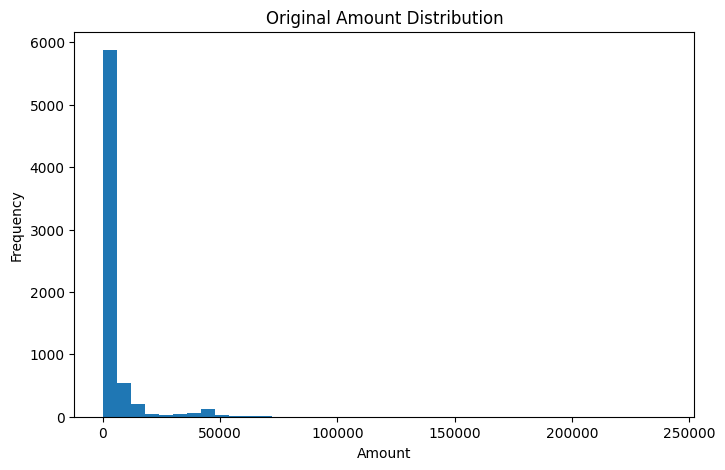

In [41]:
plt.figure(figsize=(8,5))
plt.hist(df["amount"], bins=40)
plt.title("Original Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

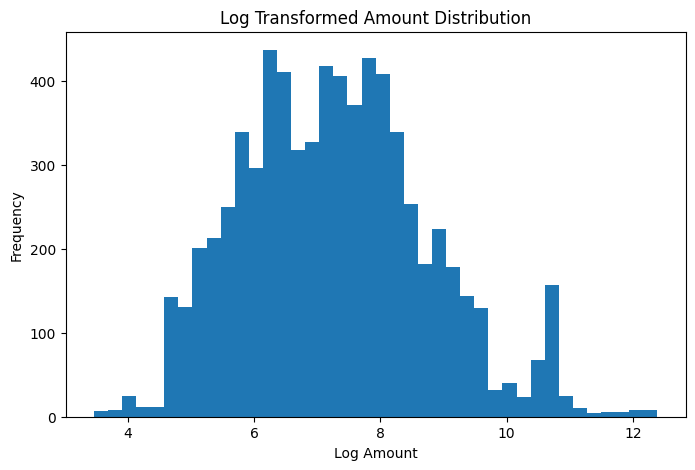

In [42]:
plt.figure(figsize=(8,5))
plt.hist(df["amount_log"], bins=40)
plt.title("Log Transformed Amount Distribution")
plt.xlabel("Log Amount")
plt.ylabel("Frequency")
plt.show()

Now We have logged amount in normal distribution ready for ml algorithm

In [43]:
print("Original Skew:", df["amount"].skew())
print("Log Skew:", df["amount_log"].skew())

Original Skew: 8.374869780946938
Log Skew: 0.3896280169075455


### Creating Amount Bucket 

In [44]:
df['amount'].quantile([0.25 , 0.50 , 0.75 , 0.90 , 0.95])

0.25      489.0300
0.50     1382.4800
0.75     3620.7175
0.90     9844.5740
0.95    20933.1420
Name: amount, dtype: float64

In [45]:
df["amount_bucket"] = pd.qcut(
    df["amount"],
    q=3,
    labels=["Small", "Medium", "Large"]
)

In [46]:
df['amount_bucket'].value_counts()

amount_bucket
Large     2334
Small     2333
Medium    2333
Name: count, dtype: int64

In [47]:
df[["amount", "amount_bucket"]].sample(20, random_state=42)

,amount,amount_bucket
6500,5801.17,Large
2944,1662.31,Medium
2024,592.19,Small
263,488.23,Small
4350,2581.50,Medium
3424,787.90,Medium
6748,3544.86,Large
6215,2693.84,Large
6362,9189.88,Large
5589,14282.70,Large


### Verifying Day , Months and Week 
If they are correctly extracted from transaction_date 

In [48]:
# Verify Day
check_day = (df["day"] == df["transaction_date"].dt.day)

print("Correct:", check_day.sum())
print("Incorrect:", (~check_day).sum())

Correct: 7000
Incorrect: 0


In [49]:
# Verify Month
check_Month = (df["month"] == df["transaction_date"].dt.month)

print("Correct:", check_Month.sum())
print("Incorrect:", (~check_Month).sum())

Correct: 7000
Incorrect: 0


In [50]:
# Verify Week   
check_week = (
    df["week"] ==
    df["transaction_date"].dt.isocalendar().week.astype(int)
)

print("Correct:", check_week.sum())
print("Incorrect:", (~check_week).sum())

Correct: 7000
Incorrect: 0


In [51]:
# Verify Weekend
expected_weekend = (
    df["transaction_date"].dt.dayofweek >= 5
).astype(int)

check_weekend = (
    df["weekend"] == expected_weekend
)

print("Correct:" , check_weekend.sum())
print("Incorrect" , (~check_weekend).sum())

Correct: 7000
Incorrect 0


In [52]:
# Verify Month End
expected_month_end = (
    df["transaction_date"]
      .dt
      .is_month_end
      .astype(int)
)

check_month_end = (
    df["month_end"] == expected_month_end
)

print("Correct:", check_month_end.sum())
print("Incorrect:", (~check_month_end).sum())

Correct: 7000
Incorrect: 0


In [53]:
# Verify Salary
expected_salary = (
    (df["transaction_date"].dt.day >= 25) | (df["transaction_date"].dt.day <= 2)   

).astype(int)

In [54]:
check_salary = (
    df["salary_week"] == expected_salary
)

print("Correct:", check_salary.sum())
print("Incorrect:", (~check_salary).sum())

Correct: 7000
Incorrect: 0


In [55]:
expected_festival = (
    df['transaction_date'].dt.month.isin([10,11,12])
)

check_festival = (
    df['festival_season']  == expected_festival
)

print("Correct:", check_festival.sum())
print("Incorrect:", (~check_festival).sum())

Correct: 7000
Incorrect: 0


In [56]:
df.dtypes

transaction_id                     object
transaction_date           datetime64[ns]
transaction_time           datetime64[ns]
merchant                           object
description                        object
amount                            float64
currency                           object
payment_method                     object
transaction_type                   object
category                           object
city                               object
state                              object
country                            object
day                                 int64
week                                int64
month                               int64
weekend                             int64
month_end                           int64
salary_week                         int64
festival_season                     int64
transaction_text                   object
transaction_text_length             int64
amount_log                        float64
amount_bucket                    c

In [57]:
date_features = ['day','week','month','weekend','month_end','salary_week','festival_season']

In [58]:
for col in date_features:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


day
day
1     227
2     248
3     246
4     240
5     243
6     236
7     192
8     200
9     213
10    233
11    226
12    235
13    205
14    215
15    225
16    218
17    202
18    230
19    233
20    192
21    226
22    222
23    192
24    228
25    211
26    258
27    253
28    243
29    268
30    267
31    173
Name: count, dtype: int64

week
week
1     133
2     125
3     115
4     127
5     147
6     130
7     134
8     156
9     183
10    183
11    153
12    126
13    172
14    166
15    159
16    181
17    174
18    168
19    140
20    129
21    148
22    176
23    161
24    145
25    144
26    184
27    138
28    158
29    139
30    159
31    158
32    128
33    137
34    120
35    190
36    155
37    149
38    157
39    184
40     83
41     62
42     82
43     71
44     80
45    103
46     69
47     66
48     87
49     93
50     93
51     72
52    108
Name: count, dtype: int64

month
month
1     561
2     596
3     697
4     745
5     651
6     681
7     667
8     626
9    

In [59]:
validation_report = pd.DataFrame({
    "Feature": [
        "day",
        "month",
        "week",
        "weekend",
        "month_end",
        "salary_week",
        "festival_season"
    ],
    "Correct": [
        check_day.sum(),
        check_Month.sum(),
        check_week.sum(),
        check_weekend.sum(),
        check_month_end.sum(),
        check_salary.sum(),
        check_festival.sum()
    ],
    "Incorrect": [
        (~check_day).sum(),
        (~check_Month).sum(),
        (~check_week).sum(),
        (~check_weekend).sum(),
        (~check_month_end).sum(),
        (~check_salary).sum(),
        (~check_festival).sum()
    ]
})

validation_report["Status"] = validation_report["Incorrect"].apply(
    lambda x: "✅ Pass" if x == 0 else "❌ Fail"
)

validation_report

,Feature,Correct,Incorrect,Status
0,day,7000,0,✅ Pass
1,month,7000,0,✅ Pass
2,week,7000,0,✅ Pass
3,weekend,7000,0,✅ Pass
4,month_end,7000,0,✅ Pass
5,salary_week,7000,0,✅ Pass
6,festival_season,7000,0,✅ Pass


### Validate and clean the categorical features before model training.

In [60]:
categorical_features = [
    "payment_method",
    "transaction_type"
]

for col in categorical_features:
    print(f"\n{col}")
    print(df[col].value_counts())


payment_method
payment_method
UPI                2607
Auto Debit         1333
Debit Card         1053
Net Banking         816
Credit Card         697
NEFT                307
Cash Withdrawal      95
IMPS                 92
Name: count, dtype: int64

transaction_type
transaction_type
Debit     6810
Credit     190
Name: count, dtype: int64


In [61]:
payment_mapping = {
    "upi": "UPI",
    "Upi": "UPI",
    "UPI": "UPI",
    "imps": "IMPS",
    "Imps": "IMPS",
    "IMPS": "IMPS",
    "neft": "NEFT",
    "Neft": "NEFT",
    "NEFT": "NEFT"
}

df["payment_method"] = (
    df["payment_method"]
    .replace(payment_mapping)
)

In [62]:
for col in categorical_features:
    print(sorted(df[col].unique()))

['Auto Debit', 'Cash Withdrawal', 'Credit Card', 'Debit Card', 'IMPS', 'NEFT', 'Net Banking', 'UPI']
['Credit', 'Debit']


In [63]:
for col in categorical_features:
    df[col] = (
        df[col]
        .str.strip()
        .str.title()
    )

In [64]:
for col in categorical_features:
    print(f"{col}: {df[col].nunique()} unique values")

payment_method: 8 unique values
transaction_type: 2 unique values


In [65]:
print(df[categorical_features].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   payment_method    7000 non-null   object
 1   transaction_type  7000 non-null   object
dtypes: object(2)
memory usage: 109.5+ KB
None


In [66]:
df[categorical_features].head()

,payment_method,transaction_type
0,Auto Debit,Debit
1,Upi,Debit
2,Credit Card,Debit
3,Upi,Debit
4,Neft,Debit


### Creating Model-Specific Feature Datasets

#### Expense Data


In [67]:
expense_df = df[
    [
        "transaction_text",
        "amount",
        "amount_log",
        "amount_bucket",
        "payment_method",
        "transaction_type",
        "category"
    ]
].copy()

In [68]:
expense_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   transaction_text  7000 non-null   object  
 1   amount            7000 non-null   float64 
 2   amount_log        7000 non-null   float64 
 3   amount_bucket     7000 non-null   category
 4   payment_method    7000 non-null   object  
 5   transaction_type  7000 non-null   object  
 6   category          7000 non-null   object  
dtypes: category(1), float64(2), object(4)
memory usage: 335.2+ KB


In [69]:
expense_df.sample(5)

,transaction_text,amount,amount_log,amount_bucket,payment_method,transaction_type,category
917,EatClub POS Purchase EatClub,147.01,4.997280,Small,Debit Card,Debit,Food
1488,Lakme Salon UPI Payment Lakme Salon,1559.99,7.353076,Medium,Upi,Debit,Miscellaneous
5140,BPCL POS Purchase BPCL,3836.16,8.252488,Large,Credit Card,Debit,Fuel
666,Netflix POS Purchase Netflix,713.08,6.570995,Medium,Credit Card,Debit,Entertainment
4501,BEST Auto Debit BEST,2684.03,7.895447,Large,Auto Debit,Debit,Bills


In [70]:
expense_df.to_csv(
    "../data/processed/expense_features.csv",
    index=False
)

#### Forecasting Dataset

In [71]:
forecast_df = df[
    [
        "transaction_date",
        "amount",
        "day",
        "week",
        "month",
        "weekend",
        "month_end",
        "salary_week",
        "festival_season"
    ]
].copy()

In [72]:
forecast_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_date  7000 non-null   datetime64[ns]
 1   amount            7000 non-null   float64       
 2   day               7000 non-null   int64         
 3   week              7000 non-null   int64         
 4   month             7000 non-null   int64         
 5   weekend           7000 non-null   int64         
 6   month_end         7000 non-null   int64         
 7   salary_week       7000 non-null   int64         
 8   festival_season   7000 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(7)
memory usage: 492.3 KB


In [73]:
forecast_df.sample(5)

,transaction_date,amount,day,week,month,weekend,month_end,salary_week,festival_season
2327,2018-03-13,2817.89,13,11,3,0,0,0,0
2385,2018-03-24,288.00,24,12,3,1,0,0,0
2678,2018-05-17,1234.84,17,20,5,0,0,0,0
5811,2018-09-25,2218.31,25,39,9,0,0,1,0
4228,2019-04-16,1007.05,16,16,4,0,0,0,0


In [74]:
forecast_df.to_csv(
    "../data/processed/forecasting_features.csv",
    index=False
)

#### Merchant Data

In [75]:
merchant_df = df[
    [
        "merchant",
        "amount",
        "category"
    ]
].copy()

In [76]:
merchant_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   merchant  7000 non-null   object 
 1   amount    7000 non-null   float64
 2   category  7000 non-null   object 
dtypes: float64(1), object(2)
memory usage: 164.2+ KB


In [77]:
merchant_df.sample(5)

,merchant,amount,category
5343,Domino's India,1520.36,Food
517,Starbucks India,162.56,Food
116,Credit Card Bill Payment,1784.99,Bills
1521,Credit Card Bill Payment,3680.65,Bills
2118,Faasos,116.00,Food


In [78]:
merchant_df.to_csv(
    "../data/processed/merchant_features.csv",
    index=False
)

In [79]:
print("Expense Shape:", expense_df.shape)
print("Forecast Shape:", forecast_df.shape)
print("Merchant Shape:", merchant_df.shape)

Expense Shape: (7000, 7)
Forecast Shape: (7000, 9)
Merchant Shape: (7000, 3)


In [80]:
print(expense_df.isnull().sum())

print(forecast_df.isnull().sum())

print(merchant_df.isnull().sum())

transaction_text    0
amount              0
amount_log          0
amount_bucket       0
payment_method      0
transaction_type    0
category            0
dtype: int64
transaction_date    0
amount              0
day                 0
week                0
month               0
weekend             0
month_end           0
salary_week         0
festival_season     0
dtype: int64
merchant    0
amount      0
category    0
dtype: int64


In [81]:
print("Expense:", expense_df.duplicated().sum())

print("Forecast:", forecast_df.duplicated().sum())

print("Merchant:", merchant_df.duplicated().sum())

Expense: 222
Forecast: 20
Merchant: 303


In [82]:
print(expense_df.dtypes)
print(forecast_df.dtypes)
print(merchant_df.dtypes)


transaction_text      object
amount               float64
amount_log           float64
amount_bucket       category
payment_method        object
transaction_type      object
category              object
dtype: object
transaction_date    datetime64[ns]
amount                     float64
day                          int64
week                         int64
month                        int64
weekend                      int64
month_end                    int64
salary_week                  int64
festival_season              int64
dtype: object
merchant     object
amount      float64
category     object
dtype: object


In [83]:
print(expense_df["payment_method"].value_counts())

print(expense_df["transaction_type"].value_counts())

print(expense_df["amount_bucket"].value_counts())

print(merchant_df["category"].value_counts())

payment_method
Upi                2607
Auto Debit         1333
Debit Card         1053
Net Banking         816
Credit Card         697
Neft                307
Cash Withdrawal      95
Imps                 92
Name: count, dtype: int64
transaction_type
Debit     6810
Credit     190
Name: count, dtype: int64
amount_bucket
Large     2334
Small     2333
Medium    2333
Name: count, dtype: int64
category
Bills            2059
Food             1328
Groceries         912
Shopping          550
Other             435
Fuel              423
Miscellaneous     358
Subscription      242
Salary            173
Entertainment     167
Rent              165
Insurance         152
Investment         36
Name: count, dtype: int64


### Data Leakage Check

In [84]:
leakage_check = pd.DataFrame({
    "Feature": [
        "transaction_text",
        "amount",
        "amount_log",
        "amount_bucket",
        "payment_method",
        "transaction_type",
        "merchant",
        "day",
        "week",
        "month",
        "weekend",
        "month_end",
        "salary_week",
        "festival_season"
    ],
    "Uses Future Data": [
        "No","No","No","No","No","No",
        "No","No","No","No","No","No","No","No"
    ],
    "Leakage Risk": [
        "Safe","Safe","Safe","Safe","Safe","Safe",
        "Safe","Safe","Safe","Safe","Safe","Safe",
        "Safe","Safe"
    ]
})

leakage_check

,Feature,Uses Future Data,Leakage Risk
0,transaction_text,No,Safe
1,amount,No,Safe
2,amount_log,No,Safe
3,amount_bucket,No,Safe
4,payment_method,No,Safe
5,transaction_type,No,Safe
6,merchant,No,Safe
7,day,No,Safe
8,week,No,Safe
9,month,No,Safe


In [85]:
leakage_check.to_csv(
    "../data/metadata/leakage_check.csv",
    index=False
)

In [86]:
required_columns = [
    "transaction_text",
    "amount",
    "amount_log",
    "payment_method",
    "transaction_type",
    "category"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

print("Missing columns:", missing_columns)

Missing columns: []


In [87]:
print(df[required_columns].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_text  7000 non-null   object 
 1   amount            7000 non-null   float64
 2   amount_log        7000 non-null   float64
 3   payment_method    7000 non-null   object 
 4   transaction_type  7000 non-null   object 
 5   category          7000 non-null   object 
dtypes: float64(2), object(4)
memory usage: 328.3+ KB
None


In [88]:
print(df[required_columns].head())

                                    transaction_text    amount  amount_log  \
0  Credit Card Bill Payment Auto Debit Credit Car...   4361.84    8.380879   
1                              Zepto UPI/Paytm/Zepto   1226.03    7.112352   
2  Ace Hardware India POS Purchase Ace Hardware I...    523.73    6.262884   
3                    Zepto UPI/DR/623175732898/Zepto   1290.29    7.163397   
4               House Rent Payment NEFT Rent Payment  44800.94   10.710007   

  payment_method transaction_type       category  
0     Auto Debit            Debit          Bills  
1            Upi            Debit      Groceries  
2    Credit Card            Debit  Miscellaneous  
3            Upi            Debit      Groceries  
4           Neft            Debit           Rent  


In [89]:
print(df["category"].value_counts())

category
Bills            2059
Food             1328
Groceries         912
Shopping          550
Other             435
Fuel              423
Miscellaneous     358
Subscription      242
Salary            173
Entertainment     167
Rent              165
Insurance         152
Investment         36
Name: count, dtype: int64


In [90]:
import os
import pandas as pd

# ---------------------------------------
# 1. Define modeling columns
# ---------------------------------------

model_columns = [
    "transaction_text",
    "amount",
    "amount_log",
    "payment_method",
    "transaction_type",
    "category"
]

# ---------------------------------------
# 2. Create modeling dataset
# ---------------------------------------

model_df = pd.read_csv('D:/clg_project/AI-Financial-Wellness-Coach/data/processed/expense_features.csv')

# ---------------------------------------
# 3. Basic verification
# ---------------------------------------

print("Shape:", model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

print("\nMissing values:")
print(model_df.isnull().sum())

print("\nData types:")
print(model_df.dtypes)

print("\nDuplicate rows:")
print(model_df.duplicated().sum())

print("\nCategory distribution:")
print(model_df["category"].value_counts())

# ---------------------------------------
# 4. Text quality checks
# ---------------------------------------

print("\nUnique transaction texts:")
print(model_df["transaction_text"].nunique())

print("\nEmpty transaction texts:")
print(
    (model_df["transaction_text"].astype(str).str.strip() == "").sum()
)

# ---------------------------------------
# 5. Create output directory
# ---------------------------------------

os.makedirs("datasets/modeling", exist_ok=True)

# ---------------------------------------
# 6. Save modeling dataset
# ---------------------------------------

# output_path = "datasets/modeling/transaction_classification.csv"

# model_df.to_csv(
#     output_path,
#     index=False
# )

# print(f"\nSaved to: {output_path}")

# ---------------------------------------
# 7. Verify saved dataset
# ---------------------------------------





Shape: (7000, 7)

Columns:
['transaction_text', 'amount', 'amount_log', 'amount_bucket', 'payment_method', 'transaction_type', 'category']

Missing values:
transaction_text    0
amount              0
amount_log          0
amount_bucket       0
payment_method      0
transaction_type    0
category            0
dtype: int64

Data types:
transaction_text     object
amount              float64
amount_log          float64
amount_bucket        object
payment_method       object
transaction_type     object
category             object
dtype: object

Duplicate rows:
222

Category distribution:
category
Bills            2059
Food             1328
Groceries         912
Shopping          550
Other             435
Fuel              423
Miscellaneous     358
Subscription      242
Salary            173
Entertainment     167
Rent              165
Insurance         152
Investment         36
Name: count, dtype: int64

Unique transaction texts:
1209

Empty transaction texts:
0


In [91]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time', 'merchant',
       'description', 'amount', 'currency', 'payment_method',
       'transaction_type', 'category', 'city', 'state', 'country', 'day',
       'week', 'month', 'weekend', 'month_end', 'salary_week',
       'festival_season', 'transaction_text', 'transaction_text_length',
       'amount_log', 'amount_bucket'],
      dtype='object')

In [93]:
df.to_csv('D:/clg_project/AI-Financial-Wellness-Coach/data/master/final_transaction_data.csv', index=False)